Importing

In [1]:
import tensorflow as tf # for neural network and loading dataset
import matplotlib.pyplot as plt # for ploting images
import numpy as np # for argmax function
from sklearn.metrics import classification_report # for classification report of model

Loading dataset
* 60,000 training images
* 10,000 testing images

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Showing first 10 images

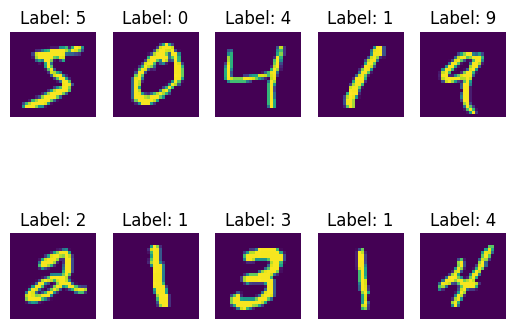

In [3]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i]) # imshow expects a 2D array of images or 3D for RGB data
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.show()

Flatten and Normalize
* Flatten = To make it able to feed it to the neural network as it expects a 1D array
* Normalize = So the model make faster and better predictions

In [4]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

Building model architecture

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,), kernel_regularizer=tf.keras.regularizers.l2(0.001)), # 256 input neurons
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.001)), # 128 hidden neurons
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.001)),  # 64 hidden neurons
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax') # 10 output neurons as the predictions are to be made between 10 digits
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compiling model

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Ploting Loss and Accuracy

In [23]:
def plot_loss(history):
  plt.plot(history.history["loss"], label="loss")
  plt.plot(history.history["val_loss"], label="val_loss")
  plt.xlabel("Epochs")
  plt.ylabel("Binary crossentropy")
  plt.legend()
  plt.grid(True)
  plt.show()

def plot_accuracy(history):
  plt.plot(history.history["accuracy"], label="accuracy")
  plt.plot(history.history["val_accuracy"], label="val_accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

Training the model

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6705 - loss: 2.5702 - val_accuracy: 0.9303 - val_loss: 0.8316
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8878 - loss: 0.9531 - val_accuracy: 0.9402 - val_loss: 0.6995
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8985 - loss: 0.8458 - val_accuracy: 0.9471 - val_loss: 0.6471
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9056 - loss: 0.7996 - val_accuracy: 0.9544 - val_loss: 0.6102
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9094 - loss: 0.7694 - val_accuracy: 0.9566 - val_loss: 0.5987
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9124 - loss: 0.7466 - val_accuracy: 0.9551 - val_loss: 0.5889
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9096 - loss: 0.7430 - val_accuracy: 0.9572 - val_loss: 0.5692
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9150 - loss: 0.

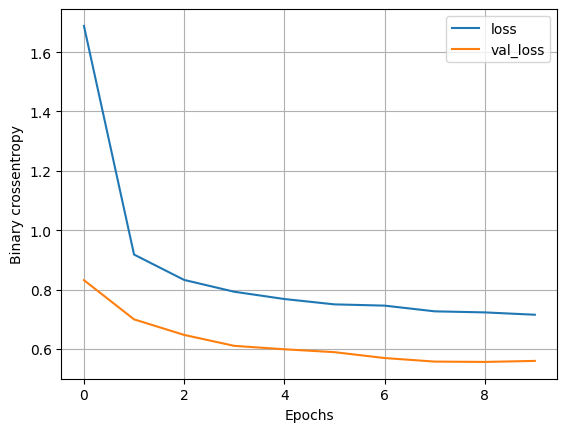

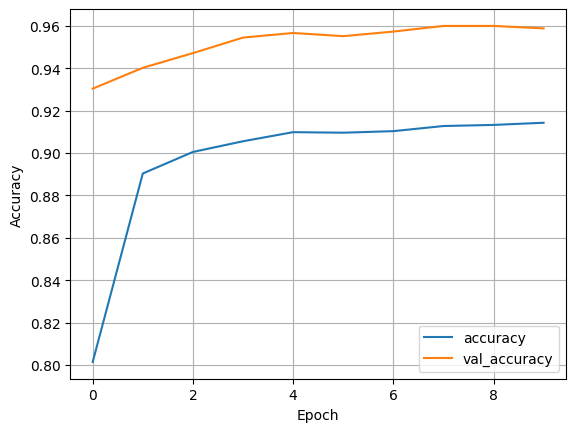

In [24]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
plot_loss(history)
plot_accuracy(history)

Making prediction

In [25]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

Classification report of the model

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.95      0.95      1032
           3       0.96      0.95      0.95      1010
           4       0.95      0.96      0.95       982
           5       0.96      0.94      0.95       892
           6       0.94      0.97      0.95       958
           7       0.94      0.96      0.95      1028
           8       0.96      0.93      0.94       974
           9       0.95      0.93      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.95     10000
weighted avg       0.96      0.96      0.96     10000

